# MobileNet Transfer Learning — Final Complete Pipeline
### CIFAR-10 | Custom CNN vs MobileNet vs MobileNetV3Small
**Includes:** Data Loading → Augmentation → Training → Fine-Tuning → Evaluation → All Visualizations

In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — Mount Google Drive
# ═══════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — Create Project Folders
# ═══════════════════════════════════════════════════════════════════
import os

PROJECT_PATH = "/content/drive/MyDrive/cnn_project"

folders = [
    "models",
    "checkpoints/mobilenet",
    "checkpoints/MobileNetV3Small",
    "figures/mobilenet",
    "figures/MobileNetV3Small",
    "results"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT_PATH, folder), exist_ok=True)

print("Project folders ready.")

Project folders ready.


In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — Imports & Mixed Precision
# ═══════════════════════════════════════════════════════════════════
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import gc
import os

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    GlobalAveragePooling2D, BatchNormalization, Input
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.applications import MobileNet, MobileNetV3Small
from tensorflow.keras.applications.mobilenet import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mobilenetv3_preprocess
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ── Enable Mixed Precision — cuts GPU/RAM usage ~50% ──────────────
tf.keras.mixed_precision.set_global_policy('mixed_float16')

print("TensorFlow version :", tf.__version__)
print("GPU available      :", tf.config.list_physical_devices('GPU'))
print("Mixed precision    :", tf.keras.mixed_precision.global_policy())

TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision    : <DTypePolicy "mixed_float16">


In [5]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — Load CIFAR-10 & Global Config
# ═══════════════════════════════════════════════════════════════════
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

NUM_CLASSES      = 10
BATCH_SIZE       = 16        # reduced to save RAM
IMG_SIZE         = 96
EPOCHS           = 20
FINE_TUNE_EPOCHS = 20
FINE_TUNE_LR     = 1e-5

CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# One-hot encode labels
y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

# Normalise for Custom CNN (32x32 stays as-is)
X_train_cnn = X_train.astype('float32') / 255.0
X_test_cnn  = X_test.astype('float32')  / 255.0

print(f"X_train : {X_train.shape}  dtype={X_train.dtype}")
print(f"X_test  : {X_test.shape}   dtype={X_test.dtype}")
print(f"Classes : {CLASS_NAMES}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
X_train : (50000, 32, 32, 3)  dtype=uint8
X_test  : (10000, 32, 32, 3)   dtype=uint8
Classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — tf.data Pipelines (lazy resize — RAM-efficient)
# ═══════════════════════════════════════════════════════════════════
def make_dataset(X, y, preprocess_fn=None, resize=False, shuffle=False):
    """Build a lazy tf.data pipeline. Only 1 batch in RAM at a time."""
    def process(image, label):
        image = tf.cast(image, tf.float32)
        if resize:
            image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
        if preprocess_fn is not None:
            image = preprocess_fn(image)
        return image, label

    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=2000, seed=42)
    ds = (ds
          .map(process, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))
    return ds

# Custom CNN  — 32x32, normalised
train_ds_cnn = make_dataset(X_train_cnn, y_train_cat, shuffle=True)
test_ds_cnn  = make_dataset(X_test_cnn,  y_test_cat)

# MobileNet   — resize to 96x96, mobilenet preprocess
train_ds_mobilenet = make_dataset(X_train, y_train_cat, mobilenet_preprocess,   resize=True, shuffle=True)
test_ds_mobilenet  = make_dataset(X_test,  y_test_cat,  mobilenet_preprocess,   resize=True)

# MobileNetV3 — resize to 96x96, mobilenetv3 preprocess
train_ds_mobilenetv3 = make_dataset(X_train, y_train_cat, mobilenetv3_preprocess, resize=True, shuffle=True)
test_ds_mobilenetv3  = make_dataset(X_test,  y_test_cat,  mobilenetv3_preprocess, resize=True)

print("tf.data pipelines ready.")

tf.data pipelines ready.


In [7]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — Data Augmentation
# ═══════════════════════════════════════════════════════════════════
data_augmentation = Sequential([
    layers.RandomRotation(0.04),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(0.1),
], name='data_augmentation')

print("Data augmentation pipeline ready.")

Data augmentation pipeline ready.


In [8]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — Callback Factory
# ═══════════════════════════════════════════════════════════════════
def make_callbacks(checkpoint_path, lr_factor=0.5, min_lr=1e-6):
    return [
        EarlyStopping(
            monitor='val_accuracy', patience=5,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=lr_factor,
            patience=3, min_lr=min_lr, verbose=1
        ),
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor='val_accuracy', save_best_only=True, verbose=1
        )
    ]

callbacks_cnn = make_callbacks(
    os.path.join(PROJECT_PATH, 'checkpoints/mobilenet/custom_cnn_best.keras'))
callbacks_mobilenet = make_callbacks(
    os.path.join(PROJECT_PATH, 'checkpoints/mobilenet/mobilenet_best.keras'))
callbacks_mobilenetv3 = make_callbacks(
    os.path.join(PROJECT_PATH, 'checkpoints/MobileNetV3Small/mobilenetv3_best.keras'))

print("Callbacks ready.")

Callbacks ready.


## Custom CNN

In [9]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8 — Build Custom CNN
# ═══════════════════════════════════════════════════════════════════
custom_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),

    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    # NOTE: dtype='float32' is required when using mixed_float16 policy
    Dense(NUM_CLASSES, activation='softmax', dtype='float32')
], name='custom_cnn')

custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

custom_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

In [10]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9 — Train Custom CNN
# ═══════════════════════════════════════════════════════════════════
print("\nTraining Custom CNN...\n")

history_custom = custom_cnn.fit(
    train_ds_cnn,
    validation_data=test_ds_cnn,
    epochs=EPOCHS,
    callbacks=callbacks_cnn,
    verbose=1
)

gc.collect()
print("\nCustom CNN training complete.")


Training Custom CNN...

Epoch 1/20
3118/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3736 - loss: 1.7285
Epoch 1: val_accuracy improved from None to 0.45290, saving model to /content/drive/MyDrive/cnn_project/checkpoints/mobilenet/custom_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/mobilenet/custom_cnn_best.keras
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - accuracy: 0.4555 - loss: 1.5150 - val_accuracy: 0.4529 - val_loss: 1.6283 - learning_rate: 0.0010
Epoch 2/20
3114/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5669 - loss: 1.2332
Epoch 2: val_accuracy improved from 0.45290 to 0.64050, saving model to /content/drive/MyDrive/cnn_project/checkpoints/mobilenet/custom_cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/mobilenet/custom_cnn_best.keras
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.5817 - loss: 1.1930 - val_accuracy: 0.6405 - val_loss: 1.0192 - learni

## MobileNet Transfer Learning

In [11]:
# ═══════════════════════════════════════════════════════════════════
# CELL 10 — Build MobileNet Model
# ═══════════════════════════════════════════════════════════════════
print("\nBuilding MobileNet Transfer Learning Model...\n")

base_model_mobilenet = MobileNet(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model_mobilenet.trainable = False   # freeze all pretrained layers

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model_mobilenet(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

mobilenet_model = Model(inputs, outputs, name='mobilenet_transfer')

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()


Building MobileNet Transfer Learning Model...



/tmp/ipykernel_545/3346698635.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model_mobilenet = MobileNet(


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_1.00_224 (Functional) │ (None, 3, 3, 1024)     │     3,228,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,361,354 (12.82 MB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [12]:
# ═══════════════════════════════════════════════════════════════════
# CELL 11 — Train MobileNet
# ═══════════════════════════════════════════════════════════════════
print("\nTraining MobileNet...\n")

history_mobilenet = mobilenet_model.fit(
    train_ds_mobilenet,
    validation_data=test_ds_mobilenet,
    epochs=EPOCHS,
    callbacks=callbacks_mobilenet,
    verbose=1
)

gc.collect()
print("\nMobileNet initial training complete.")


Training MobileNet...

Epoch 1/20
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6445 - loss: 1.0632
Epoch 1: val_accuracy improved from None to 0.81290, saving model to /content/drive/MyDrive/cnn_project/checkpoints/mobilenet/mobilenet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/mobilenet/mobilenet_best.keras
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 75s 17ms/step - accuracy: 0.7029 - loss: 0.8632 - val_accuracy: 0.8129 - val_loss: 0.5243 - learning_rate: 0.0010
Epoch 2/20
3122/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7473 - loss: 0.7248
Epoch 2: val_accuracy improved from 0.81290 to 0.82970, saving model to /content/drive/MyDrive/cnn_project/checkpoints/mobilenet/mobilenet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/mobilenet/mobilenet_best.keras
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - accuracy: 0.7515 - loss: 0.7135 - val_accuracy: 0.8297 - val_loss: 0.4913 - learnin

## MobileNetV3Small Transfer Learning

In [13]:
# ═══════════════════════════════════════════════════════════════════
# CELL 12 — Build MobileNetV3Small Model
# ═══════════════════════════════════════════════════════════════════
print("\nBuilding MobileNetV3Small Transfer Learning Model...\n")

base_model_v3 = MobileNetV3Small(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model_v3.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model_v3(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

mobilenetv3_model = Model(inputs, outputs, name='mobilenetv3_transfer')

mobilenetv3_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenetv3_model.summary()


Building MobileNetV3Small Transfer Learning Model...



/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv3_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 3, 3, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,266 (3.87 MB)

 Trainable params: 75,146 (293.54 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [14]:
# ═══════════════════════════════════════════════════════════════════
# CELL 13 — Train MobileNetV3Small
# ═══════════════════════════════════════════════════════════════════
print("\nTraining MobileNetV3Small...\n")

history_mobilenetv3 = mobilenetv3_model.fit(
    train_ds_mobilenetv3,
    validation_data=test_ds_mobilenetv3,
    epochs=EPOCHS,
    callbacks=callbacks_mobilenetv3,
    verbose=1
)

gc.collect()
print("\nMobileNetV3Small initial training complete.")


Training MobileNetV3Small...

Epoch 1/20
3121/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5865 - loss: 1.1822
Epoch 1: val_accuracy improved from None to 0.74910, saving model to /content/drive/MyDrive/cnn_project/checkpoints/MobileNetV3Small/mobilenetv3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/MobileNetV3Small/mobilenetv3_best.keras
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 78s 18ms/step - accuracy: 0.6405 - loss: 1.0231 - val_accuracy: 0.7491 - val_loss: 0.7177 - learning_rate: 0.0010
Epoch 2/20
3121/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6811 - loss: 0.9082
Epoch 2: val_accuracy improved from 0.74910 to 0.76210, saving model to /content/drive/MyDrive/cnn_project/checkpoints/MobileNetV3Small/mobilenetv3_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/MobileNetV3Small/mobilenetv3_best.keras
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 55s 18ms/step - accuracy: 0.6846 - loss: 0.8983 - val_ac

## Fine-Tuning

In [15]:
# ═══════════════════════════════════════════════════════════════════
# CELL 14 — Fine-Tune MobileNet (unfreeze last 30 layers)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("FINE-TUNING MobileNet")
print("="*60)
print(f"Total layers in base: {len(base_model_mobilenet.layers)}")

UNFREEZE_FROM = -30
base_model_mobilenet.trainable = True

for layer in base_model_mobilenet.layers[:UNFREEZE_FROM]:
    layer.trainable = False
for layer in base_model_mobilenet.layers[UNFREEZE_FROM:]:
    layer.trainable = True

trainable = sum(1 for l in base_model_mobilenet.layers if l.trainable)
frozen    = sum(1 for l in base_model_mobilenet.layers if not l.trainable)
print(f"Trainable layers : {trainable}")
print(f"Frozen layers    : {frozen}")

# Recompile with 100x smaller learning rate
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ft_callbacks_mobilenet = make_callbacks(
    os.path.join(PROJECT_PATH, 'checkpoints/mobilenet/mobilenet_ft_best.keras'),
    lr_factor=0.3, min_lr=1e-7
)

initial_offset_mn = len(history_mobilenet.history['accuracy'])
print(f"\nContinuing from epoch {initial_offset_mn}...\n")

history_mobilenet_ft = mobilenet_model.fit(
    train_ds_mobilenet,
    validation_data=test_ds_mobilenet,
    epochs=initial_offset_mn + FINE_TUNE_EPOCHS,
    initial_epoch=initial_offset_mn,
    callbacks=ft_callbacks_mobilenet,
    verbose=1
)

gc.collect()
print("\nMobileNet fine-tuning complete.")


FINE-TUNING MobileNet
Total layers in base: 86
Trainable layers : 30
Frozen layers    : 56

Continuing from epoch 20...

Epoch 21/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6915 - loss: 1.0337
Epoch 21: val_accuracy improved from None to 0.84490, saving model to /content/drive/MyDrive/cnn_project/checkpoints/mobilenet/mobilenet_ft_best.keras

Epoch 21: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/mobilenet/mobilenet_ft_best.keras
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 107s 27ms/step - accuracy: 0.7149 - loss: 0.9247 - val_accuracy: 0.8449 - val_loss: 0.4783 - learning_rate: 1.0000e-05
Epoch 22/40
3124/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7534 - loss: 0.7662
Epoch 22: val_accuracy improved from 0.84490 to 0.86190, saving model to /content/drive/MyDrive/cnn_project/checkpoints/mobilenet/mobilenet_ft_best.keras

Epoch 22: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/mobilenet/mobilenet_ft_best.keras
3125/3125

In [16]:
# ═══════════════════════════════════════════════════════════════════
# CELL 15 — Fine-Tune MobileNetV3Small (unfreeze last 20 layers)
# ═══════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("FINE-TUNING MobileNetV3Small")
print("="*60)
print(f"Total layers in base: {len(base_model_v3.layers)}")

UNFREEZE_FROM_V3 = -20
base_model_v3.trainable = True

for layer in base_model_v3.layers[:UNFREEZE_FROM_V3]:
    layer.trainable = False
for layer in base_model_v3.layers[UNFREEZE_FROM_V3:]:
    layer.trainable = True

trainable = sum(1 for l in base_model_v3.layers if l.trainable)
frozen    = sum(1 for l in base_model_v3.layers if not l.trainable)
print(f"Trainable layers : {trainable}")
print(f"Frozen layers    : {frozen}")

mobilenetv3_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ft_callbacks_mobilenetv3 = make_callbacks(
    os.path.join(PROJECT_PATH, 'checkpoints/MobileNetV3Small/mobilenetv3_ft_best.keras'),
    lr_factor=0.3, min_lr=1e-7
)

initial_offset_v3 = len(history_mobilenetv3.history['accuracy'])
print(f"\nContinuing from epoch {initial_offset_v3}...\n")

history_mobilenetv3_ft = mobilenetv3_model.fit(
    train_ds_mobilenetv3,
    validation_data=test_ds_mobilenetv3,
    epochs=initial_offset_v3 + FINE_TUNE_EPOCHS,
    initial_epoch=initial_offset_v3,
    callbacks=ft_callbacks_mobilenetv3,
    verbose=1
)

gc.collect()
print("\nMobileNetV3Small fine-tuning complete.")


FINE-TUNING MobileNetV3Small
Total layers in base: 157
Trainable layers : 20
Frozen layers    : 137

Continuing from epoch 20...

Epoch 21/40
3123/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6144 - loss: 1.2296
Epoch 21: val_accuracy improved from None to 0.76760, saving model to /content/drive/MyDrive/cnn_project/checkpoints/MobileNetV3Small/mobilenetv3_ft_best.keras

Epoch 21: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/MobileNetV3Small/mobilenetv3_ft_best.keras
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 96s 26ms/step - accuracy: 0.6346 - loss: 1.1390 - val_accuracy: 0.7676 - val_loss: 0.6815 - learning_rate: 1.0000e-05
Epoch 22/40
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6653 - loss: 0.9971
Epoch 22: val_accuracy improved from 0.76760 to 0.77660, saving model to /content/drive/MyDrive/cnn_project/checkpoints/MobileNetV3Small/mobilenetv3_ft_best.keras

Epoch 22: finished saving model to /content/drive/MyDrive/cnn_project/checkpoints/MobileNe

## Evaluation

In [17]:
# ═══════════════════════════════════════════════════════════════════
# CELL 16 — Evaluation Function
# ═══════════════════════════════════════════════════════════════════
def evaluate_model(model, dataset, y_true_raw, model_name):
    """Predict on dataset, compute all metrics, print classification report."""
    y_pred_probs = model.predict(dataset, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)
    y_true       = y_true_raw.flatten()

    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
    f1        = f1_score(y_true, y_pred,        average='weighted', zero_division=0)

    print(f"\n{'='*52}")
    print(f"  {model_name}")
    print(f"{'='*52}")
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    return accuracy, precision, recall, f1, y_pred

print("Evaluation function defined.")

Evaluation function defined.


In [18]:
# ═══════════════════════════════════════════════════════════════════
# CELL 17 — Evaluate All 5 Models
# ═══════════════════════════════════════════════════════════════════
print("\nRunning evaluation on all models...\n")

custom_metrics         = evaluate_model(custom_cnn,        test_ds_cnn,          y_test, "Custom CNN")
mobilenet_metrics      = evaluate_model(mobilenet_model,   test_ds_mobilenet,    y_test, "MobileNet (Initial)")
mobilenetv3_metrics    = evaluate_model(mobilenetv3_model, test_ds_mobilenetv3,  y_test, "MobileNetV3Small (Initial)")
mobilenet_ft_metrics   = evaluate_model(mobilenet_model,   test_ds_mobilenet,    y_test, "MobileNet (Fine-Tuned)")
mobilenetv3_ft_metrics = evaluate_model(mobilenetv3_model, test_ds_mobilenetv3,  y_test, "MobileNetV3Small (Fine-Tuned)")


Running evaluation on all models...


  Custom CNN
  Accuracy  : 0.7952
  Precision : 0.7961
  Recall    : 0.7952
  F1-Score  : 0.7948

Classification Report:
              precision    recall  f1-score   support

    airplane       0.82      0.80      0.81      1000
  automobile       0.92      0.87      0.90      1000
        bird       0.76      0.66      0.70      1000
         cat       0.63      0.67      0.65      1000
        deer       0.76      0.78      0.77      1000
         dog       0.72      0.71      0.72      1000
        frog       0.84      0.86      0.85      1000
       horse       0.82      0.81      0.82      1000
        ship       0.87      0.90      0.88      1000
       truck       0.81      0.91      0.86      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.79     10000
weighted avg       0.80      0.80      0.79     10000


  MobileNet (Initial)
  Accuracy  : 0.9155
  Precision : 0.9153
  Recall    : 0.

In [19]:
# ═══════════════════════════════════════════════════════════════════
# CELL 18 — Performance Comparison Table + CSV
# ═══════════════════════════════════════════════════════════════════
all_metrics = [
    ("Custom CNN",                     custom_metrics),
    ("MobileNet (Initial)",            mobilenet_metrics),
    ("MobileNet (Fine-Tuned)",         mobilenet_ft_metrics),
    ("MobileNetV3Small (Initial)",     mobilenetv3_metrics),
    ("MobileNetV3Small (Fine-Tuned)",  mobilenetv3_ft_metrics),
]

comparison_df = pd.DataFrame({
    'Model'    : [m[0] for m in all_metrics],
    'Accuracy' : [m[1][0] for m in all_metrics],
    'Precision': [m[1][1] for m in all_metrics],
    'Recall'   : [m[1][2] for m in all_metrics],
    'F1-Score' : [m[1][3] for m in all_metrics],
})

for col in ['Accuracy','Precision','Recall','F1-Score']:
    comparison_df[col] = comparison_df[col].map('{:.4f}'.format)

print("\n" + "="*68)
print("  FINAL PERFORMANCE COMPARISON")
print("="*68)
print(comparison_df.to_string(index=False))

csv_path = os.path.join(PROJECT_PATH, 'results/performance_comparison.csv')
comparison_df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")


  FINAL PERFORMANCE COMPARISON
                        Model Accuracy Precision Recall F1-Score
                   Custom CNN   0.7952    0.7961 0.7952   0.7948
          MobileNet (Initial)   0.9155    0.9153 0.9155   0.9151
       MobileNet (Fine-Tuned)   0.9155    0.9153 0.9155   0.9151
   MobileNetV3Small (Initial)   0.8233    0.8231 0.8233   0.8216
MobileNetV3Small (Fine-Tuned)   0.8233    0.8231 0.8233   0.8216

Saved: /content/drive/MyDrive/cnn_project/results/performance_comparison.csv


## Training History Plots

Saved: /content/drive/MyDrive/cnn_project/figures/mobilenet/history_custom_cnn.png


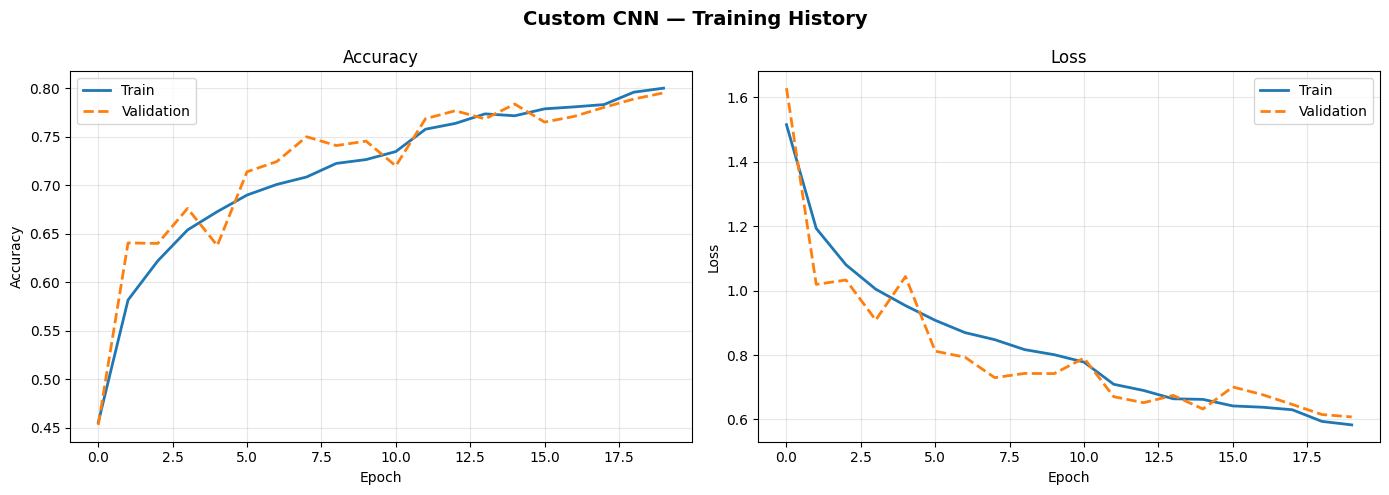

Saved: /content/drive/MyDrive/cnn_project/figures/mobilenet/history_mobilenet.png


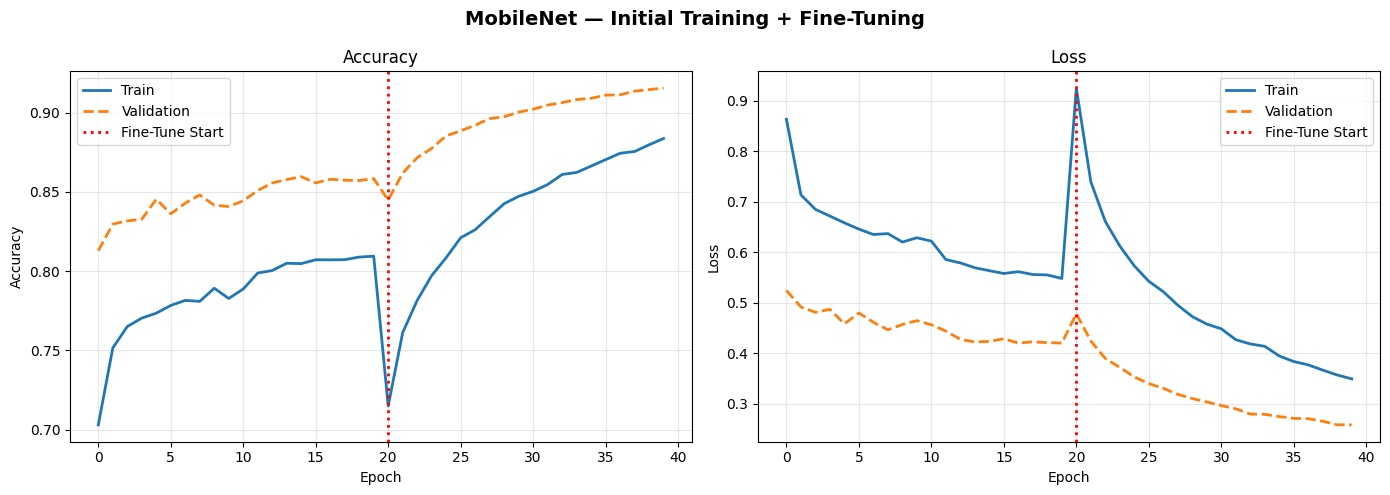

Saved: /content/drive/MyDrive/cnn_project/figures/MobileNetV3Small/history_mobilenetv3.png


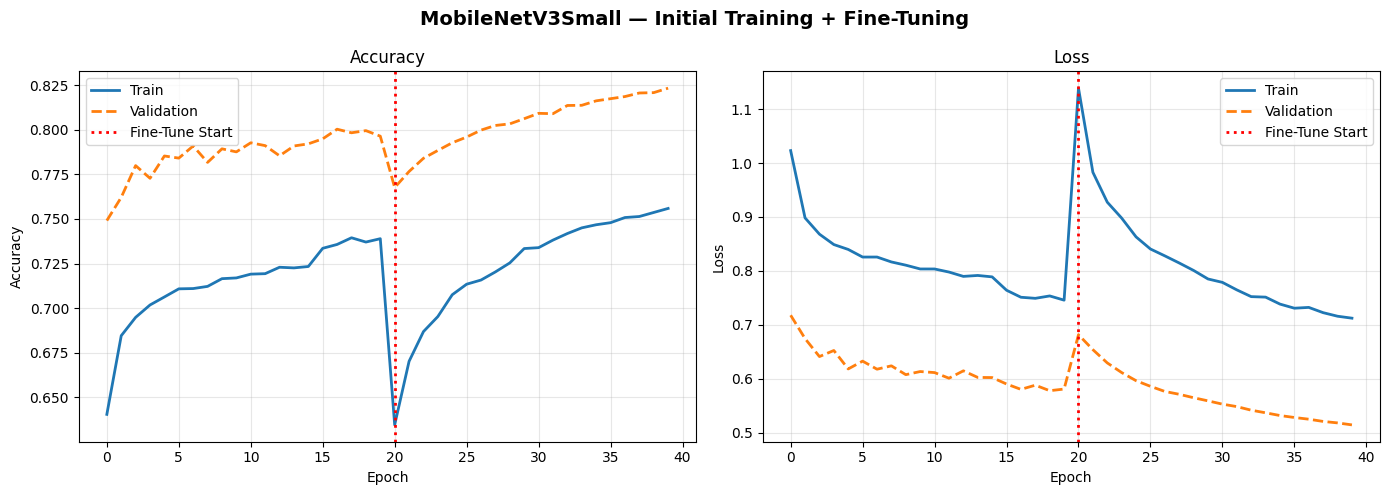

In [20]:
# ═══════════════════════════════════════════════════════════════════
# CELL 19 — Training History Plots
# ═══════════════════════════════════════════════════════════════════
def plot_history(history, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    axes[0].plot(history.history['accuracy'],     label='Train',      linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2, linestyle='--')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'],     label='Train',      linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2, linestyle='--')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


def plot_finetune_comparison(h_init, h_ft, title, save_path=None):
    """Merge initial + fine-tune histories — red dashed line marks ft start."""
    acc      = h_init.history['accuracy']     + h_ft.history['accuracy']
    val_acc  = h_init.history['val_accuracy'] + h_ft.history['val_accuracy']
    loss     = h_init.history['loss']         + h_ft.history['loss']
    val_loss = h_init.history['val_loss']     + h_ft.history['val_loss']
    ft_start = len(h_init.history['accuracy'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for ax, y1, y2, ylabel in zip(
        axes,
        [acc, loss], [val_acc, val_loss],
        ['Accuracy', 'Loss']
    ):
        ax.plot(y1, label='Train',           linewidth=2)
        ax.plot(y2, label='Validation',      linewidth=2, linestyle='--')
        ax.axvline(x=ft_start, color='red',  linewidth=2, linestyle=':', label='Fine-Tune Start')
        ax.set_title(ylabel); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


# ── Plot all ───────────────────────────────────────────────────────
plot_history(
    history_custom, 'Custom CNN — Training History',
    os.path.join(PROJECT_PATH, 'figures/mobilenet/history_custom_cnn.png')
)
plot_finetune_comparison(
    history_mobilenet, history_mobilenet_ft,
    'MobileNet — Initial Training + Fine-Tuning',
    os.path.join(PROJECT_PATH, 'figures/mobilenet/history_mobilenet.png')
)
plot_finetune_comparison(
    history_mobilenetv3, history_mobilenetv3_ft,
    'MobileNetV3Small — Initial Training + Fine-Tuning',
    os.path.join(PROJECT_PATH, 'figures/MobileNetV3Small/history_mobilenetv3.png')
)

## Confusion Matrices

Saved: /content/drive/MyDrive/cnn_project/figures/mobilenet/cm_custom_cnn.png


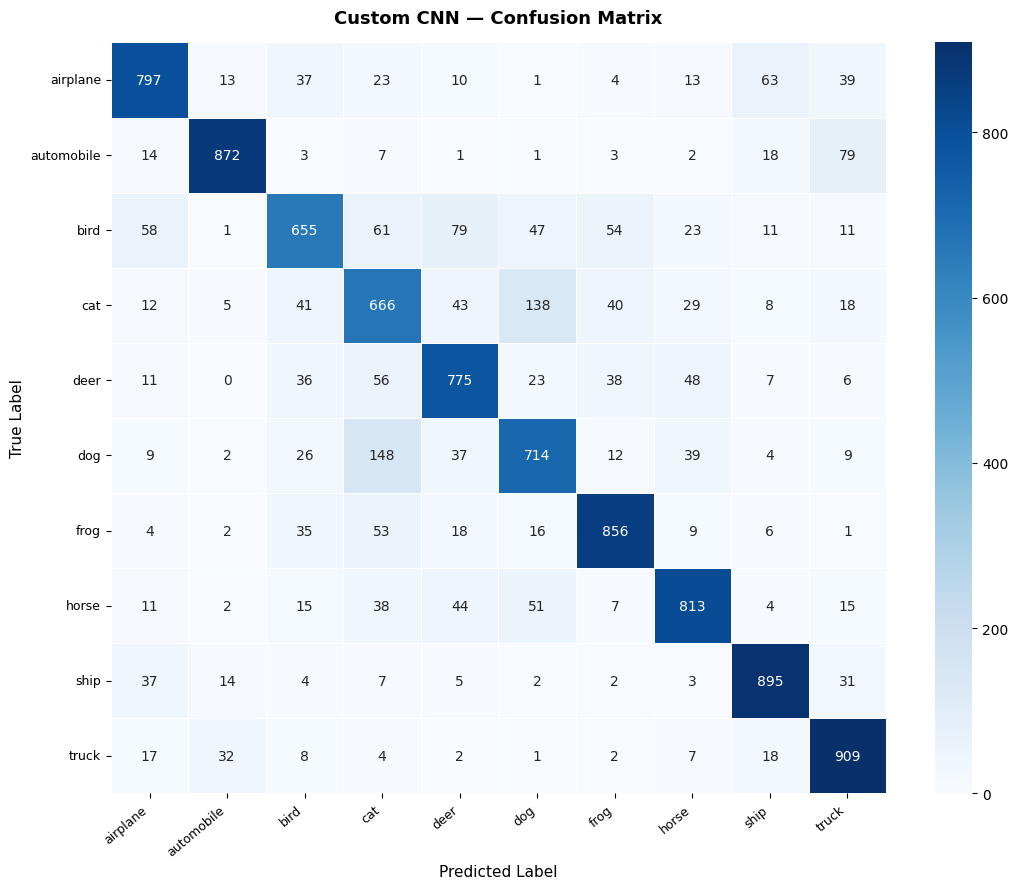

Saved: /content/drive/MyDrive/cnn_project/figures/mobilenet/cm_mobilenet_initial.png


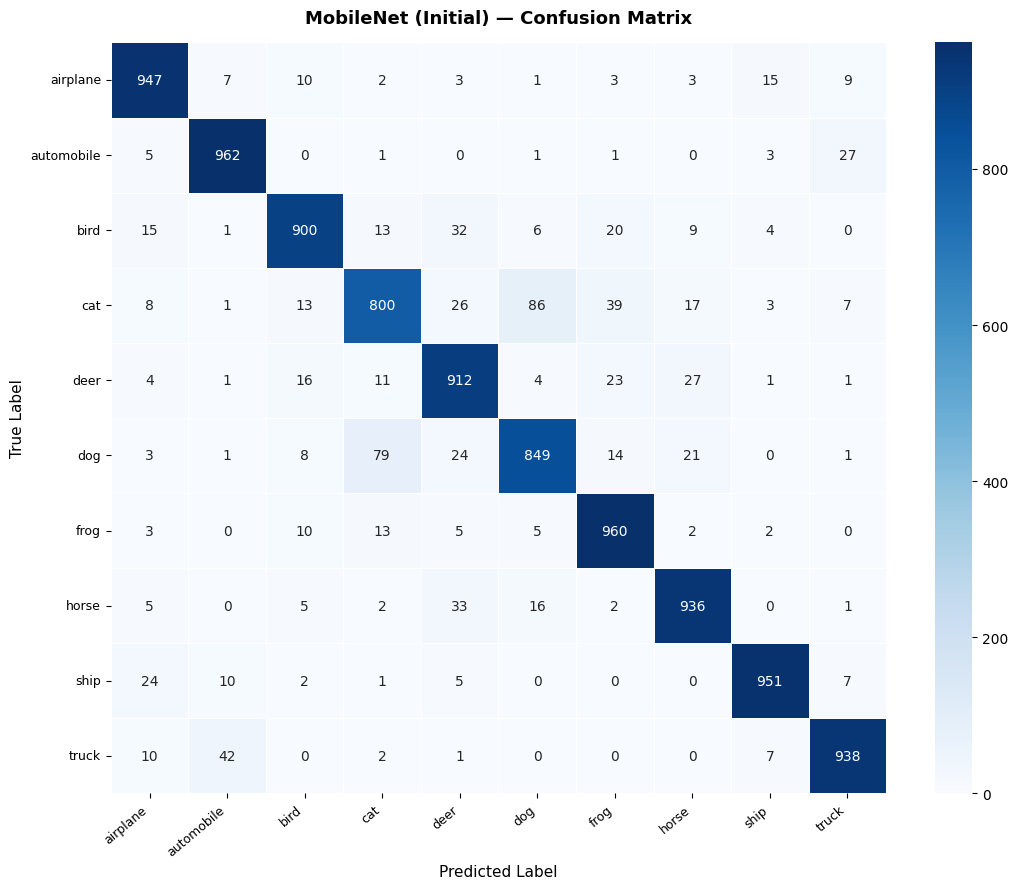

Saved: /content/drive/MyDrive/cnn_project/figures/mobilenet/cm_mobilenet_finetuned.png


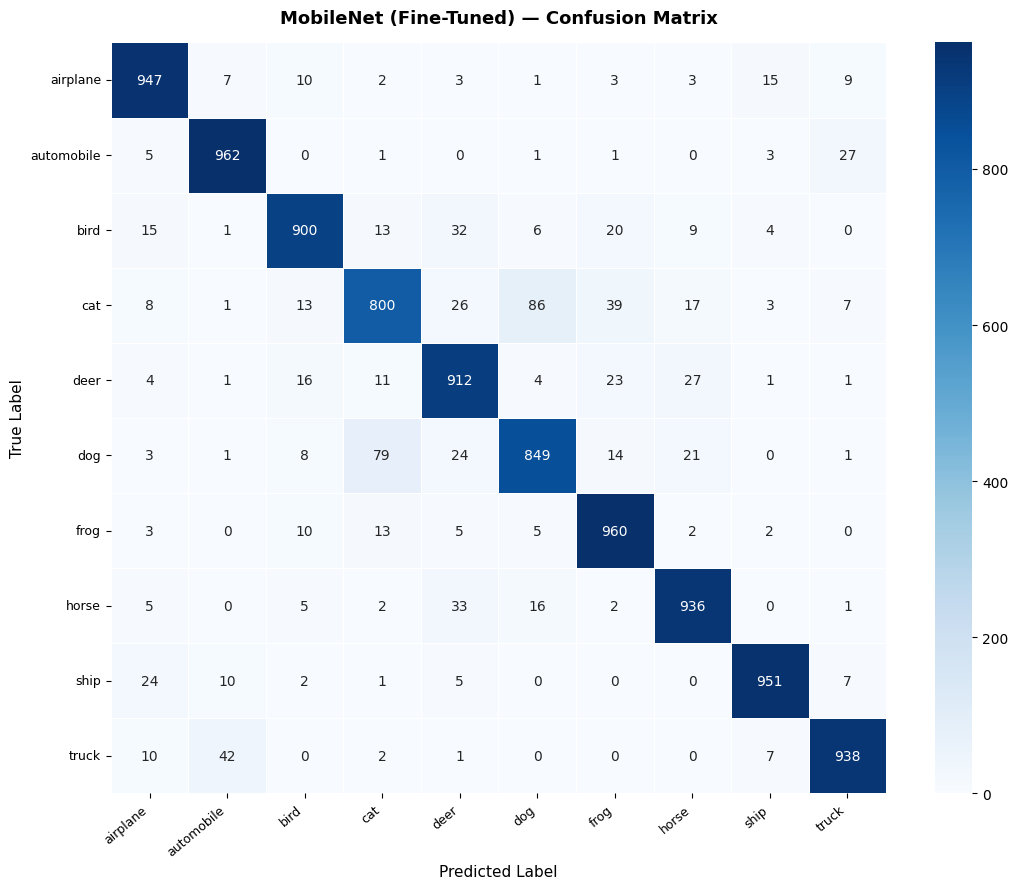

Saved: /content/drive/MyDrive/cnn_project/figures/MobileNetV3Small/cm_mobilenetv3_initial.png


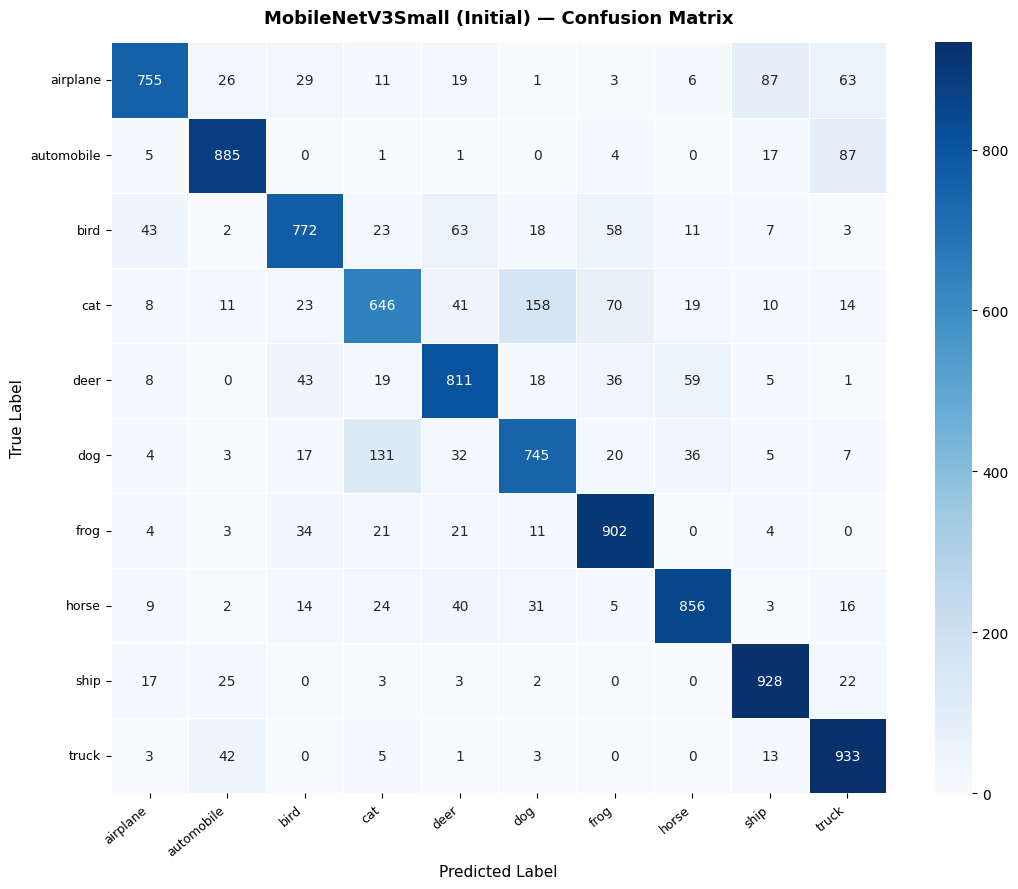

Saved: /content/drive/MyDrive/cnn_project/figures/MobileNetV3Small/cm_mobilenetv3_finetuned.png


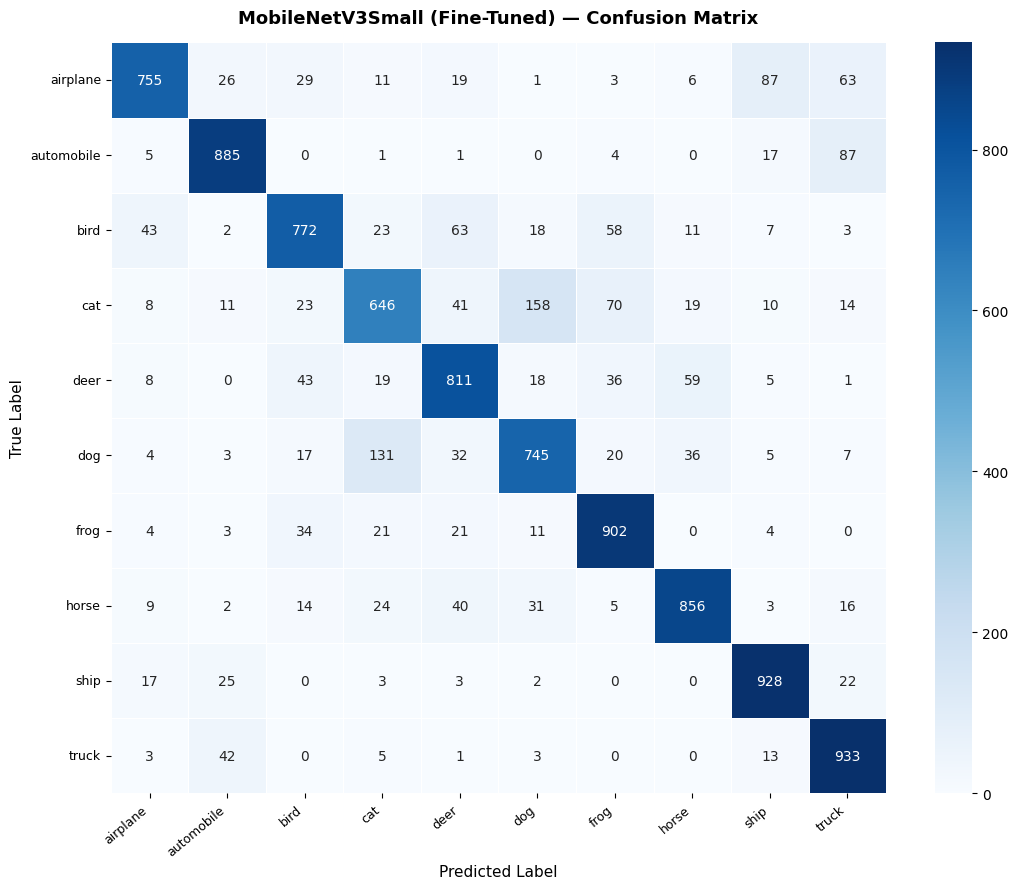

In [21]:
# ═══════════════════════════════════════════════════════════════════
# CELL 20 — Confusion Matrices (all 5 models)
# ═══════════════════════════════════════════════════════════════════
def plot_confusion_matrix(y_true, y_pred, title, save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(11, 9))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.4, linecolor='white'
    )
    plt.title(title, fontsize=13, fontweight='bold', pad=14)
    plt.xlabel('Predicted Label', fontsize=11)
    plt.ylabel('True Label', fontsize=11)
    plt.xticks(rotation=40, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()

y_flat = y_test.flatten()

plot_confusion_matrix(y_flat, custom_metrics[4],
    'Custom CNN — Confusion Matrix',
    os.path.join(PROJECT_PATH, 'figures/mobilenet/cm_custom_cnn.png'))

plot_confusion_matrix(y_flat, mobilenet_metrics[4],
    'MobileNet (Initial) — Confusion Matrix',
    os.path.join(PROJECT_PATH, 'figures/mobilenet/cm_mobilenet_initial.png'))

plot_confusion_matrix(y_flat, mobilenet_ft_metrics[4],
    'MobileNet (Fine-Tuned) — Confusion Matrix',
    os.path.join(PROJECT_PATH, 'figures/mobilenet/cm_mobilenet_finetuned.png'))

plot_confusion_matrix(y_flat, mobilenetv3_metrics[4],
    'MobileNetV3Small (Initial) — Confusion Matrix',
    os.path.join(PROJECT_PATH, 'figures/MobileNetV3Small/cm_mobilenetv3_initial.png'))

plot_confusion_matrix(y_flat, mobilenetv3_ft_metrics[4],
    'MobileNetV3Small (Fine-Tuned) — Confusion Matrix',
    os.path.join(PROJECT_PATH, 'figures/MobileNetV3Small/cm_mobilenetv3_finetuned.png'))

## Metrics Bar Chart

Saved: /content/drive/MyDrive/cnn_project/figures/mobilenet/metrics_comparison_bar.png


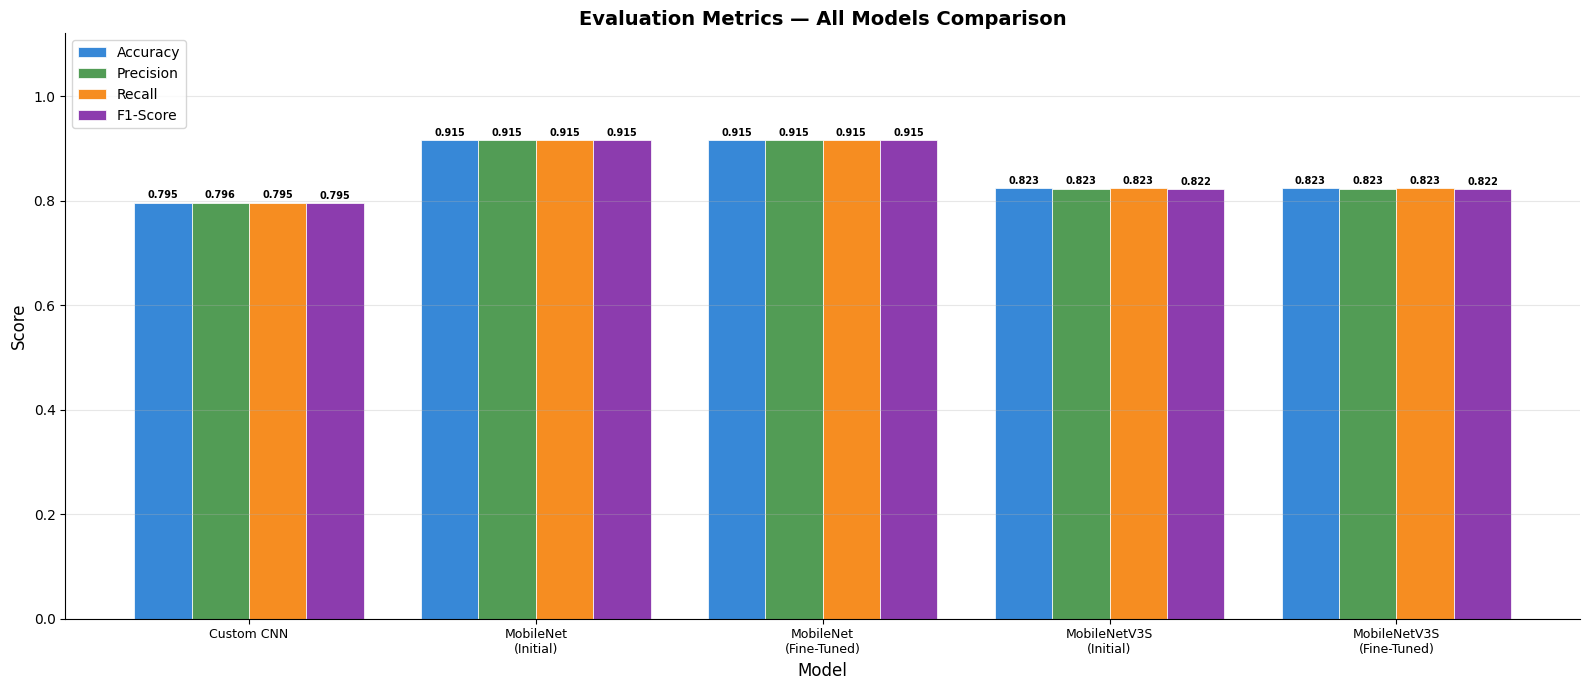

In [22]:
# ═══════════════════════════════════════════════════════════════════
# CELL 21 — Evaluation Metrics Bar Chart (all models side-by-side)
# ═══════════════════════════════════════════════════════════════════
model_labels = [
    'Custom CNN',
    'MobileNet\n(Initial)',
    'MobileNet\n(Fine-Tuned)',
    'MobileNetV3S\n(Initial)',
    'MobileNetV3S\n(Fine-Tuned)'
]

metric_values = {
    'Accuracy' : [custom_metrics[0], mobilenet_metrics[0], mobilenet_ft_metrics[0],
                  mobilenetv3_metrics[0], mobilenetv3_ft_metrics[0]],
    'Precision': [custom_metrics[1], mobilenet_metrics[1], mobilenet_ft_metrics[1],
                  mobilenetv3_metrics[1], mobilenetv3_ft_metrics[1]],
    'Recall'   : [custom_metrics[2], mobilenet_metrics[2], mobilenet_ft_metrics[2],
                  mobilenetv3_metrics[2], mobilenetv3_ft_metrics[2]],
    'F1-Score' : [custom_metrics[3], mobilenet_metrics[3], mobilenet_ft_metrics[3],
                  mobilenetv3_metrics[3], mobilenetv3_ft_metrics[3]],
}

x      = np.arange(len(model_labels))
width  = 0.20
colors = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']

fig, ax = plt.subplots(figsize=(16, 7))

for i, (metric, color) in enumerate(zip(metric_values, colors)):
    bars = ax.bar(x + (i - 1.5) * width, metric_values[metric],
                  width, label=metric, color=color, alpha=0.87, edgecolor='white', linewidth=0.6)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Evaluation Metrics — All Models Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=9)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
save_path = os.path.join(PROJECT_PATH, 'figures/mobilenet/metrics_comparison_bar.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved: {save_path}")
plt.show()

## Per-Class Accuracy

Saved: /content/drive/MyDrive/cnn_project/figures/mobilenet/per_class_accuracy.png


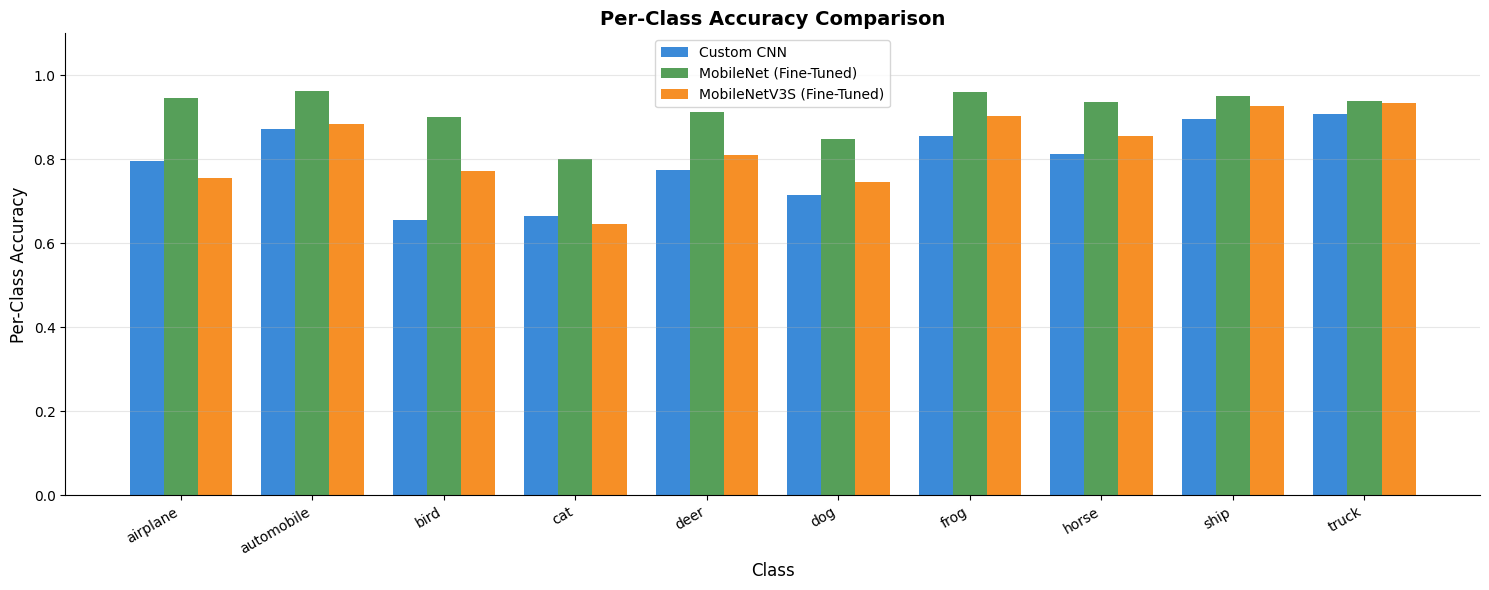

In [23]:
# ═══════════════════════════════════════════════════════════════════
# CELL 22 — Per-Class Accuracy Bar Chart
# ═══════════════════════════════════════════════════════════════════
def per_class_accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return cm.diagonal() / cm.sum(axis=1)

y_flat = y_test.flatten()

acc_custom = per_class_accuracy(y_flat, custom_metrics[4])
acc_mn_ft  = per_class_accuracy(y_flat, mobilenet_ft_metrics[4])
acc_v3_ft  = per_class_accuracy(y_flat, mobilenetv3_ft_metrics[4])

x     = np.arange(len(CLASS_NAMES))
width = 0.26

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(x - width, acc_custom, width, label='Custom CNN',                color='#1976D2', alpha=0.85)
ax.bar(x,         acc_mn_ft,  width, label='MobileNet (Fine-Tuned)',    color='#388E3C', alpha=0.85)
ax.bar(x + width, acc_v3_ft,  width, label='MobileNetV3S (Fine-Tuned)', color='#F57C00', alpha=0.85)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Per-Class Accuracy', fontsize=12)
ax.set_title('Per-Class Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0, 1.10)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
save_path = os.path.join(PROJECT_PATH, 'figures/mobilenet/per_class_accuracy.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved: {save_path}")
plt.show()

## Sample Predictions

Saved: /content/drive/MyDrive/cnn_project/figures/mobilenet/pred_custom_cnn.png


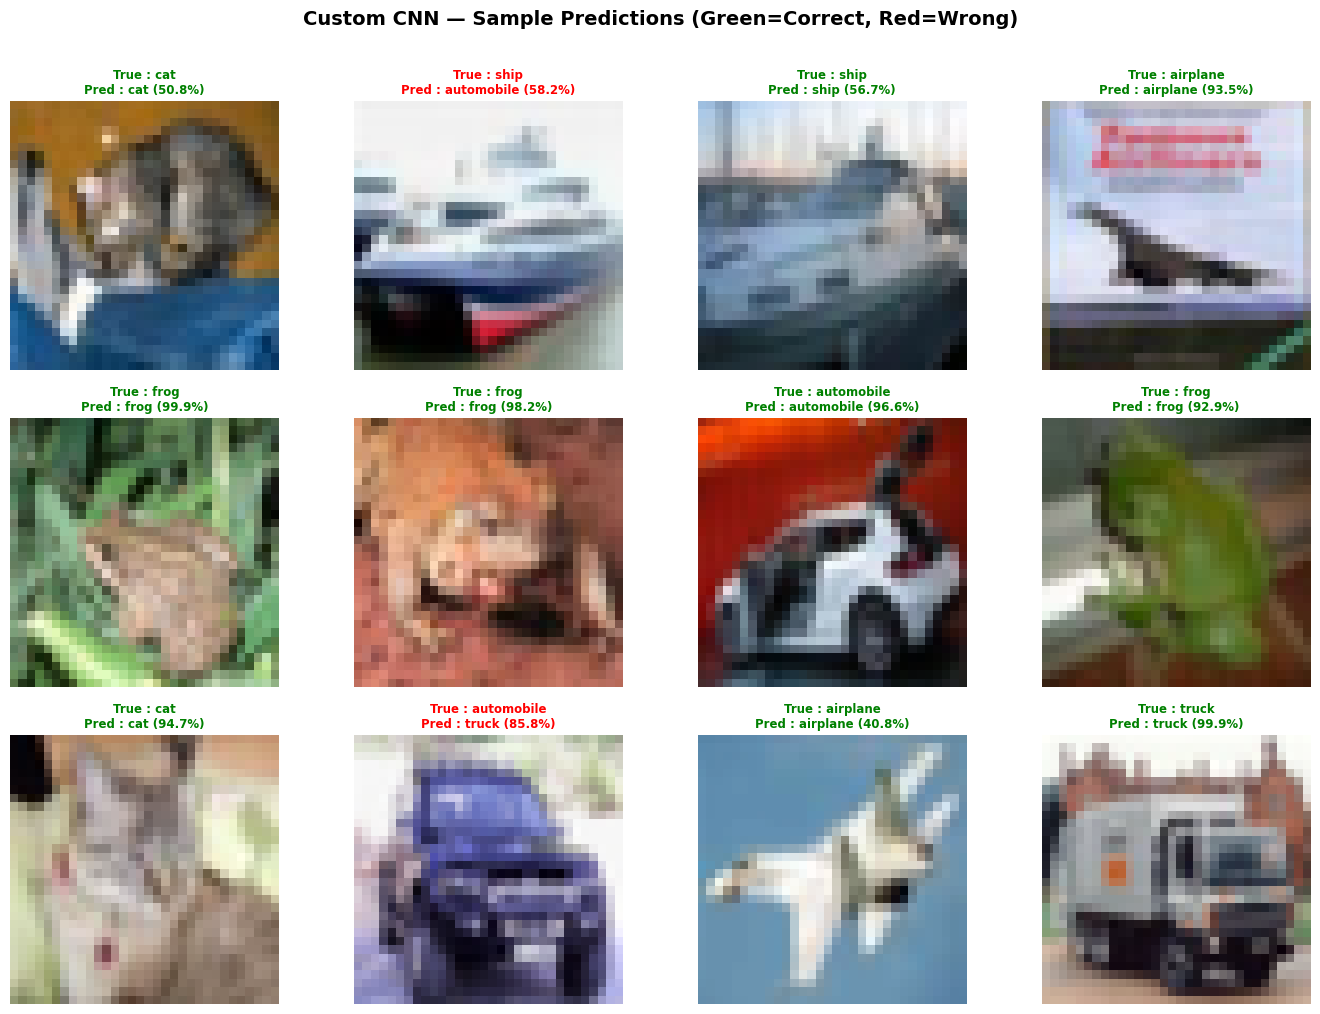

Saved: /content/drive/MyDrive/cnn_project/figures/mobilenet/pred_mobilenet_ft.png


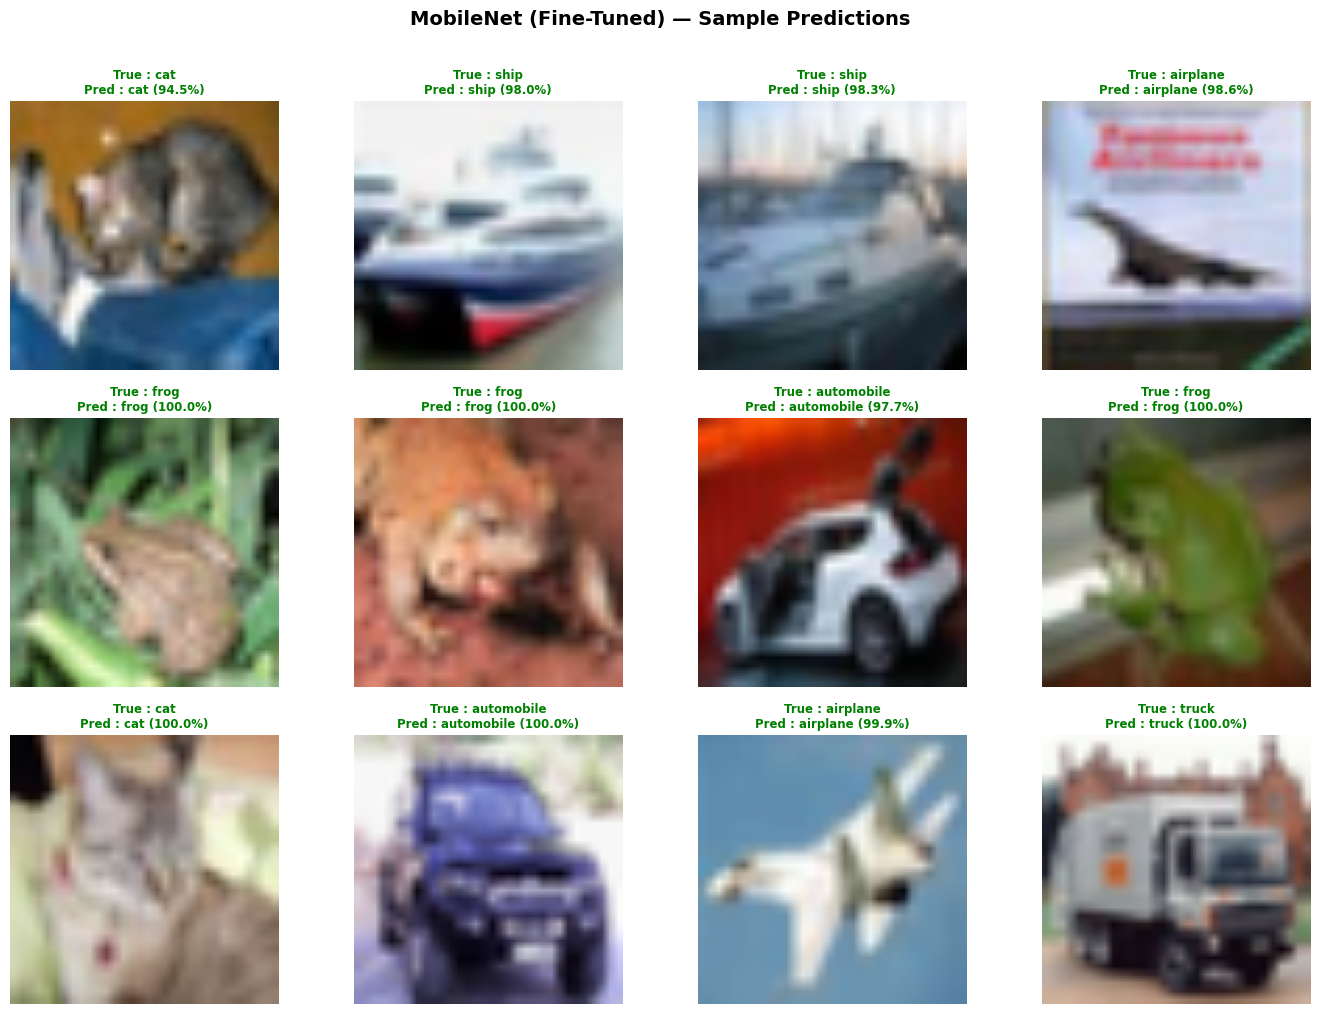

Saved: /content/drive/MyDrive/cnn_project/figures/MobileNetV3Small/pred_mobilenetv3_ft.png


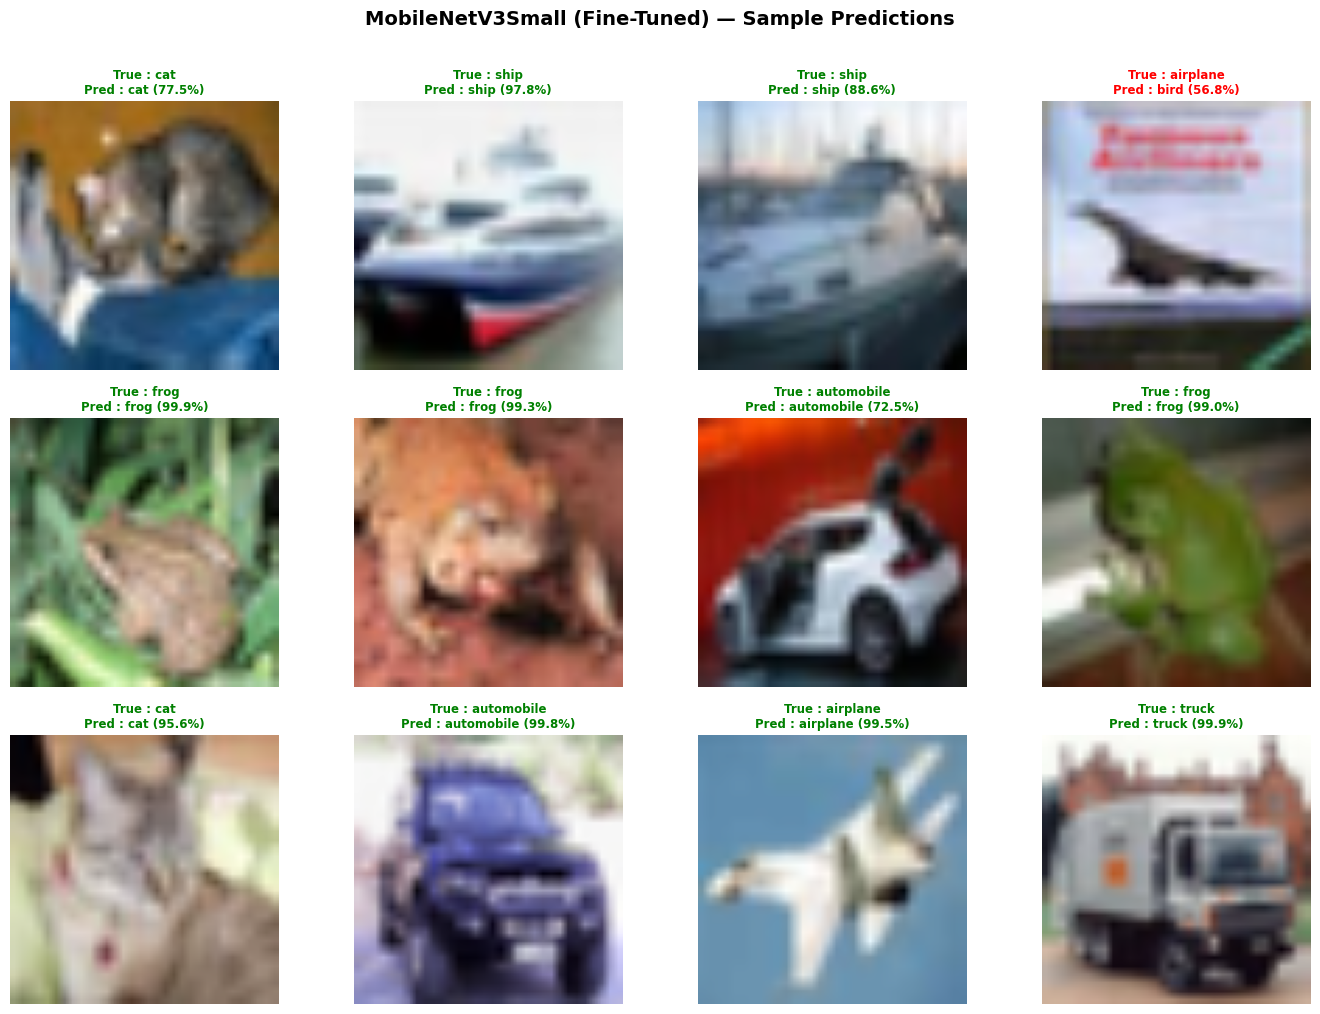

In [24]:
# ═══════════════════════════════════════════════════════════════════
# CELL 23 — Sample Predictions Grid (12 images per model)
# ═══════════════════════════════════════════════════════════════════
def show_predictions(model, dataset, y_test_raw, class_names, title, save_path=None):
    """Show 12 sample predictions. Green title = correct, Red = wrong."""
    # Take first batch and use first 12 images
    sample_images, _ = next(iter(dataset))
    sample_images    = sample_images[:12]

    pred_probs   = model.predict(sample_images, verbose=0)
    pred_classes = np.argmax(pred_probs, axis=1)

    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)

    for i, ax in enumerate(axes.flat):
        img = sample_images[i].numpy().astype('float32')
        # Normalise pixel range to [0,1] for display
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = np.clip(img, 0, 1)

        ax.imshow(img)

        true_label = class_names[y_test_raw[i][0]]
        pred_label = class_names[pred_classes[i]]
        confidence = np.max(pred_probs[i]) * 100
        color      = 'green' if true_label == pred_label else 'red'

        ax.set_title(
            f"True : {true_label}\nPred : {pred_label} ({confidence:.1f}%)",
            color=color, fontsize=8.5, fontweight='bold'
        )
        ax.axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


show_predictions(
    custom_cnn, test_ds_cnn, y_test, CLASS_NAMES,
    'Custom CNN — Sample Predictions (Green=Correct, Red=Wrong)',
    os.path.join(PROJECT_PATH, 'figures/mobilenet/pred_custom_cnn.png')
)

show_predictions(
    mobilenet_model, test_ds_mobilenet, y_test, CLASS_NAMES,
    'MobileNet (Fine-Tuned) — Sample Predictions',
    os.path.join(PROJECT_PATH, 'figures/mobilenet/pred_mobilenet_ft.png')
)

show_predictions(
    mobilenetv3_model, test_ds_mobilenetv3, y_test, CLASS_NAMES,
    'MobileNetV3Small (Fine-Tuned) — Sample Predictions',
    os.path.join(PROJECT_PATH, 'figures/MobileNetV3Small/pred_mobilenetv3_ft.png')
)

## Save Models

In [25]:
# ═══════════════════════════════════════════════════════════════════
# CELL 24 — Save All Models
# ═══════════════════════════════════════════════════════════════════
custom_cnn.save(os.path.join(PROJECT_PATH,        'models/custom_cnn.keras'))
mobilenet_model.save(os.path.join(PROJECT_PATH,   'models/mobilenet_finetuned.keras'))
mobilenetv3_model.save(os.path.join(PROJECT_PATH, 'models/mobilenetv3_finetuned.keras'))

print("\nAll models saved.")
print(f"Location: {PROJECT_PATH}/models/")
print("  custom_cnn.keras")
print("  mobilenet_finetuned.keras")
print("  mobilenetv3_finetuned.keras")
print("\nAll figures saved to:")
print(f"  {PROJECT_PATH}/figures/")
print("\nResults CSV saved to:")
print(f"  {PROJECT_PATH}/results/performance_comparison.csv")


All models saved.
Location: /content/drive/MyDrive/cnn_project/models/
  custom_cnn.keras
  mobilenet_finetuned.keras
  mobilenetv3_finetuned.keras

All figures saved to:
  /content/drive/MyDrive/cnn_project/figures/

Results CSV saved to:
  /content/drive/MyDrive/cnn_project/results/performance_comparison.csv
